In [3]:
import pandas as pd
import numpy as np 

df = pd.read_csv("ai4i2020.csv")
df.head()
df.shape
df.info()
df.isna().sum().sort_values(ascending=False)
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [3]:
df["Machine failure"].unique()


array([0, 1])

In [4]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

Observación importante:

El dataset presenta desbalance de clases.
Solo el 3.39% de las observaciones corresponden a fallos de máquina.

Esto es típico en escenarios industriales reales donde los eventos críticos son poco frecuentes.

In [5]:
df.groupby("Machine failure")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


Observaciones preliminares:

- Las máquinas que fallan presentan mayor desgaste de herramienta (Tool wear).
- El torque promedio es considerablemente mayor en casos con fallo.
- La velocidad rotacional es ligeramente menor en casos con fallo.
- Las temperaturas no muestran diferencias tan marcadas.

Hipótesis:
El desgaste acumulado y el torque elevado podrían estar asociados a mayor probabilidad de fallo.

In [8]:
df.groupby("Machine failure")["Tool wear [min]"].mean()
df.groupby("Machine failure")["Torque [Nm]"].mean()

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

In [9]:
df["Torque [Nm]"].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

In [10]:
df["Tool wear [min]"].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

In [11]:
df["wear_bin"] = pd.cut(df["Tool wear [min]"], bins=5)

failure_rate = df.groupby("wear_bin")["Machine failure"].mean()

failure_rate

wear_bin
(-0.253, 50.6]    0.021703
(50.6, 101.2]     0.024148
(101.2, 151.8]    0.021007
(151.8, 202.4]    0.030069
(202.4, 253.0]    0.168155
Name: Machine failure, dtype: float64

## Análisis por rangos de desgaste

Se observa que la tasa de fallo permanece relativamente estable (~2-3%) 
en la mayoría de los rangos de desgaste.

Sin embargo, cuando el desgaste supera aproximadamente 200 minutos,
la tasa de fallo aumenta drásticamente hasta ~16.8%.

Esto sugiere la posible existencia de un umbral crítico de desgaste
a partir del cual el riesgo de fallo aumenta significativamente.

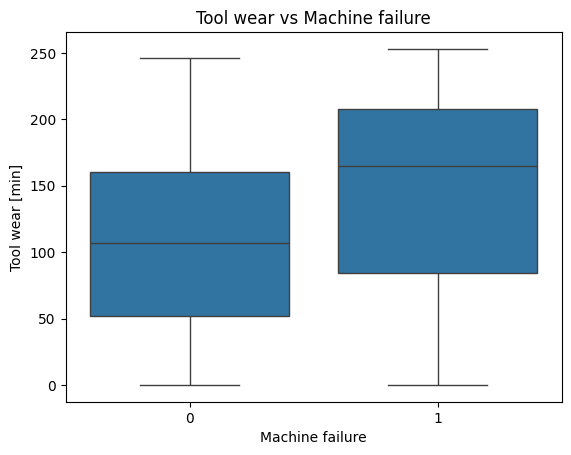

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)
plt.title("Tool wear vs Machine failure")
plt.show()

## Visualización: desgaste de herramienta vs fallo de máquina

El boxplot muestra que las máquinas que fallan presentan niveles de desgaste de herramienta
considerablemente más altos que aquellas que no fallan.

La mediana del desgaste en máquinas con fallo es significativamente mayor, y una gran parte
de los casos de fallo se concentra en valores superiores a ~150 minutos de desgaste.

Esto refuerza la hipótesis de que el desgaste acumulado de la herramienta es un factor
relevante asociado a la probabilidad de fallo en la maquinaria.

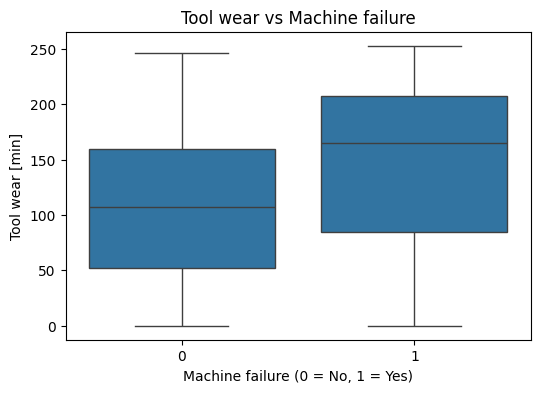

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)

plt.title("Tool wear vs Machine failure")
plt.xlabel("Machine failure (0 = No, 1 = Yes)")
plt.ylabel("Tool wear [min]")

plt.show()

## Interpretación del boxplot

El boxplot muestra que las máquinas que presentan fallo (Machine failure = 1)
tienen niveles de desgaste de herramienta significativamente mayores.

La mediana del desgaste en máquinas con fallo es superior a la de máquinas
sin fallo, y la distribución se desplaza hacia valores más altos, lo cual
refuerza la hipótesis de que el desgaste acumulado de la herramienta está
asociado con una mayor probabilidad de fallo.

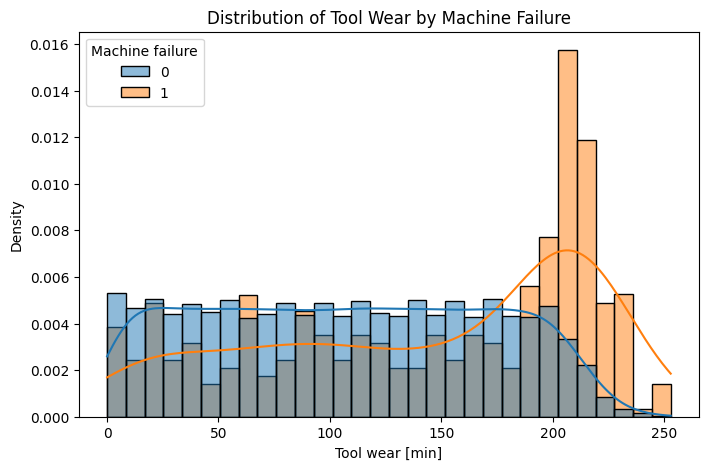

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x="Tool wear [min]",
             hue="Machine failure",
             bins=30,
             kde=True,
             stat="density",
             common_norm=False)

plt.title("Distribution of Tool Wear by Machine Failure")
plt.xlabel("Tool wear [min]")
plt.ylabel("Density")

plt.show()

## Interpretación de la distribución del desgaste

La distribución muestra que los casos de fallo de máquina (Machine failure = 1)
se concentran principalmente en valores altos de desgaste de herramienta.

En particular, se observa una mayor densidad de fallos cuando el desgaste supera
aproximadamente los 200 minutos.

Esto sugiere que el desgaste acumulado de la herramienta podría ser un factor
relevante en la probabilidad de fallo de la maquinaria.

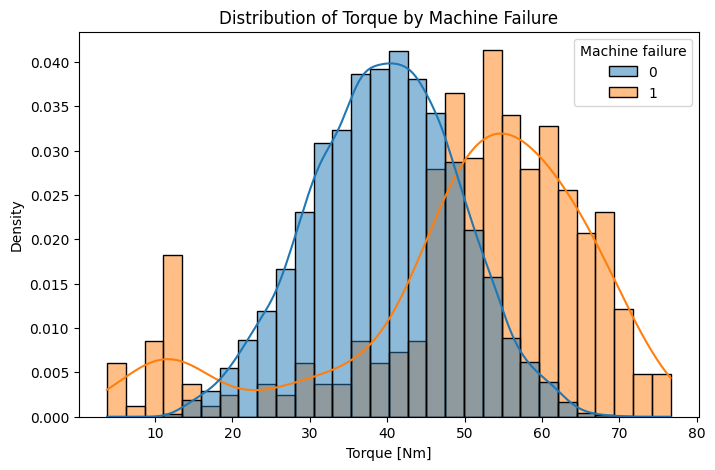

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x="Torque [Nm]",
             hue="Machine failure",
             bins=30,
             kde=True,
             stat="density",
             common_norm=False)

plt.title("Distribution of Torque by Machine Failure")
plt.xlabel("Torque [Nm]")
plt.ylabel("Density")

plt.show()

## Interpretación de la distribución de Torque

La distribución muestra que las máquinas que presentan fallos
(Machine failure = 1) tienden a operar con valores de torque
considerablemente más altos.

Mientras que las máquinas sin fallo se concentran aproximadamente
entre 30 y 45 Nm, los casos de fallo presentan mayor densidad
entre 50 y 65 Nm.

Esto sugiere que niveles elevados de torque podrían estar asociados
a una mayor probabilidad de fallo de la maquinaria.

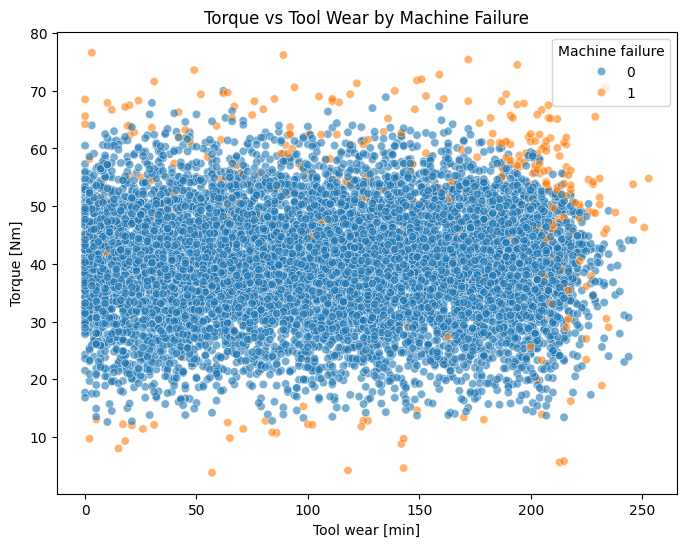

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.6
)

plt.title("Torque vs Tool Wear by Machine Failure")
plt.xlabel("Tool wear [min]")
plt.ylabel("Torque [Nm]")

plt.show()

## Relación entre torque, desgaste y fallos

El gráfico de dispersión sugiere que los casos de fallo de máquina
(Machine failure = 1) tienden a concentrarse en regiones donde
el desgaste de herramienta es elevado, particularmente por encima
de los 200 minutos.

Además, varios de estos casos también presentan valores de torque
relativamente altos.

Esto sugiere que la combinación de desgaste acumulado de la herramienta
y niveles elevados de torque podría estar asociada a una mayor
probabilidad de fallo de la maquinaria.

Este patrón es consistente con análisis previos donde se observó
que los fallos presentan mayores valores promedio de desgaste
y torque.

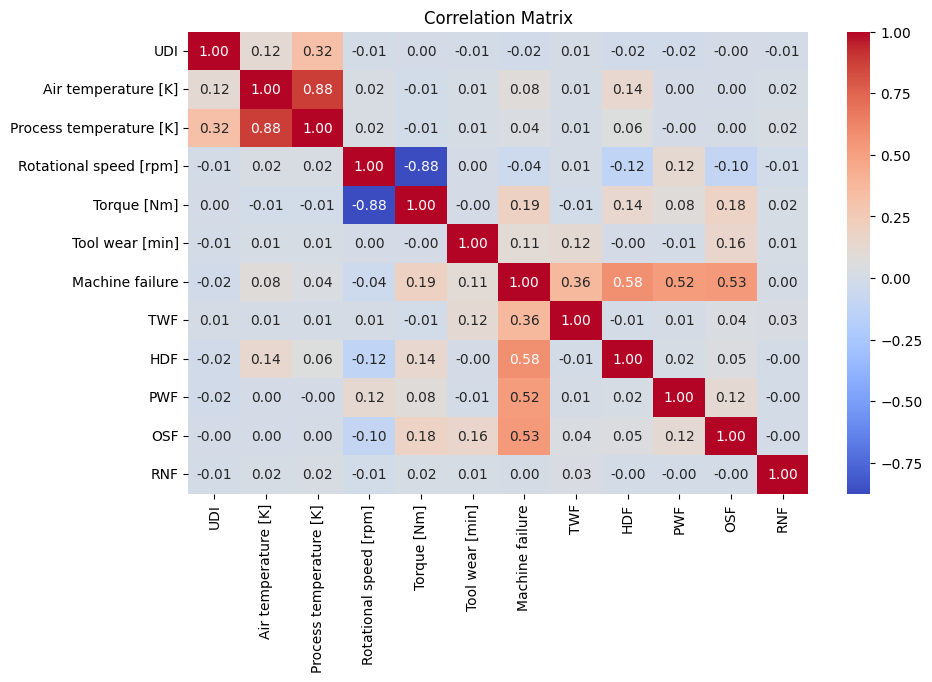

In [9]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## Correlation analysis

El mapa de correlaciones muestra que las variables con mayor asociación
con el fallo de máquina son aquellas relacionadas directamente con tipos
específicos de fallo (HDF, PWF, OSF y TWF), lo cual es esperado dado que
representan diferentes categorías de fallos del sistema.

Entre las variables operativas de la máquina, el torque (0.19) y el
desgaste de herramienta (0.11) presentan las correlaciones positivas
más relevantes con la variable de fallo.

Esto es consistente con los análisis previos, donde se observó que
los casos de fallo tienden a presentar mayores niveles de torque
y mayor desgaste acumulado de la herramienta.

Adicionalmente, se observa una fuerte correlación negativa entre
la velocidad rotacional y el torque (-0.88), lo cual refleja el
comportamiento mecánico típico en sistemas rotacionales.